# Reinforcement Learning

Reinforcement learning algorithms solve MDP-based control problems having the agent interact with
the environment (i.e., sampling) and learning from its experience. In order to do so, the agent will
try to maximize the expected return, or _expected cumulative reward_ (reward hypothesis).

## Type of Tasks

Before we proceed, let's introduce some useful concepts. There are two types of RL tasks:

- **Episodic:** The task has one or more end (or _terminal_) states. For example, our grid world
  robot task ends either in the bomb or in the target.
- **Continuous:** The task never ends, there are no terminal states. The agent keeps interacting
  with the environment (e.g., stock trading agent).

## Approaches

Finally, there are two main approaches for solving an RL problem:

- **Value-based:** The agent learns an optimal value function (e.g., $Q(s,a)$), and then derives the
  optimal policy from it (see previous lecture). For now, we will focus on these methods.
- **Policy-based:** The agent learns an optimal policy directly. We will learn about a popular
  category of algorithms of this kind later on (i.e., _policy gradient_ methods).


In [1]:
# For reproducibility.
from util.gymnastics import init_random

init_random()

## An Updated Grid World

To examine our RL algorithms, we will use a slightly more complicated version of our grid world.


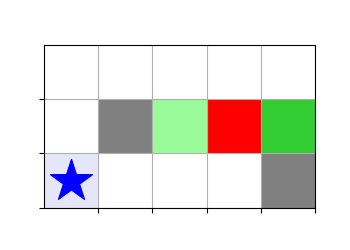

In [2]:
from util.gridworld import Grid, GridMDP, run_simulation, RANDOM_POLICY

WORLD_GRID = Grid(
    [
        "EEEEE",
        "EWTNG",
        "SEEEW",
    ]
)

MDP = GridMDP(WORLD_GRID, gamma=0.9)

run_simulation(MDP, RANDOM_POLICY)

## Exponential Smoothing

How do we refine the expected value of a variable `X` given a series of samples? One technique that
we will use extensively is iteratively applying an
[_exponential moving average_](https://en.wikipedia.org/wiki/Exponential_smoothing) of the samples.

$$
X_{t+1} =  (1 - \alpha) X_t + \alpha X_{t+1}
$$

Basically, the adjusted value after sampling is a "blend" of the old value adjusted by the scaled
value of the new sample. $\alpha$ is the scaling factor (or, _learning rate_). We can rewrite the
above as:

$$
X_{t+1} =  X_t + \alpha (X_{t+1} - X_t)
$$

Where the difference between the new and old value is effectively an error $\delta$ scaled by the
learning rate $\alpha$. You will see why this formula is very important shortly.


In [3]:
import numpy as np

# Samples 1M values from a normal distribution with mean pi.
samples = np.random.normal(loc=3.14159265, scale=1.618033, size=(1_000_000,))


def estimate_mean(samples, alpha=0.0001) -> float:
    """Approximates the expected value using exponential smoothing."""
    value = samples[0]
    for sample in samples[1:]:
        value = value + alpha * (sample - value)
    return value


# This should print a value very close to 3.14 :)
print(f"Estimated expected value: {estimate_mean(samples):.2f}")

Estimated expected value: 3.15


## Monte Carlo Methods

Monte Carlo methods apply to episodic tasks. The intuition is that we can simulate entire episodes
and compute the actual return with which we can then update our value function.

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [G_t - Q(S_t, A_t)]
$$

Monte Carlo methods do not introduce _bias_ in the estimation (because they use the actual return at
the end of the episode), but they might have high _variance_.


### Episode Generation


In [4]:
from util.gridworld import GridEnv, State, Action
from typing import Callable, TypeAlias

# For simplicity, we define a policy as a function that returns an action given a state.
Policy: TypeAlias = Callable[[State], Action]

# An episode instead is a list of tuples (state, action, reward).
Episode: TypeAlias = list[tuple[State, Action, float]]

In [5]:
# Test our definition
assert Policy == Callable[[State], Action]
assert Episode == list[tuple[State, Action, float]]

In [6]:
def generate_episode(env: GridEnv, policy: Policy, max_t=10) -> Episode:
    """Generates an Monte Carlo episode in the Grid World environment GridEnv.

    `max_t` caps episode length so a degenerate policy (e.g., one that bounces between
    cells) cannot spin forever; 10 steps is plenty for our 3x5 grid.
    """
    t = 0
    episode = []
    state = env.reset()
    while t < max_t:
        action: Action = policy(state)
        next, reward, done = env.step(action)
        episode.append((state, action, reward))
        state = next
        t = t + 1
        if done:
            break
    return episode

In [7]:
# Test
test_env = GridEnv(MDP)
test_policy = lambda _: Action.LEFT
test_episode = generate_episode(test_env, test_policy, max_t=3)
assert len(test_episode) == 3
assert test_episode[0] == (State(0, 0), Action.LEFT, 0.0)
assert test_episode[1] == (State(0, 0), Action.LEFT, 0.0)
assert test_episode[2] == (State(0, 0), Action.LEFT, 0.0)

test_policy = lambda s: Action.UP if s == State(3, 0) else Action.RIGHT
test_episode = generate_episode(test_env, test_policy)
assert len(test_episode) == 4
assert test_episode[0] == (State(0, 0), Action.RIGHT, 0.0)
assert test_episode[1] == (State(1, 0), Action.RIGHT, 0.0)
assert test_episode[2] == (State(2, 0), Action.RIGHT, 0.0)
# Stepping UP from (3, 0) lands on the NUKE cell (3, 1) — environment reward is -10.0
# (we no longer scale rewards by gamma inside the env).
assert test_episode[3] == (State(3, 0), Action.UP, -10.0)

But _how_ do we choose the actions in our Monte Carlo algorithm?


### Greedy and ε-greedy Policy

A _greedy_ policy always chooses the action that maximizes the Q function in the current state.

An _ε-greedy_ policy chooses any other action (other than the best action) with probability
$\frac{\epsilon}{n_A}$, where $n_A$ is the number of available actions. Hence, if ε is `1`, the
policy becomes the random policy; if ε is `0`, the policy is greedy instead.


In [8]:
from util.gridworld import QTable


def greedy_policy(qtable: QTable) -> Policy:
    """Returns the greedy policy for the specified QTable."""
    return lambda s: qtable.best_action(s)

In [9]:
# Test the implementation
state_0 = State(0, 0)
state_1 = State(1, 0)
test_qtable = QTable([state_0, state_1], list(Action))

test_qtable[state_0, Action.DOWN] = 0.5
test_qtable[state_0, Action.LEFT] = 1.5
test_qtable[state_0, Action.RIGHT] = 0.8
test_qtable[state_1, Action.UP] = 0.1

test_greedy_policy = greedy_policy(test_qtable)

assert test_greedy_policy(state_0) == Action.LEFT
assert test_greedy_policy(state_1) == Action.UP

In [10]:
from util.gridworld import QTable


def epsilon_greedy_policy(qtable: QTable, epsilon: float) -> Policy:
    """Returns the epsilon-greedy policy for the specified QTable."""

    def choose_action(state: State):
        nA = qtable.nA
        other_probs = np.ones(nA) * epsilon / nA
        best_action = qtable.best_action(state)
        best_action_idx = qtable.actions.index(best_action)
        other_probs[best_action_idx] = 1 - epsilon + (epsilon / nA)
        return np.random.choice(qtable.actions, p=other_probs)

    return choose_action

In [11]:
# Test the implementation
# Approximate tests... hopefully good enough to find big bugs :)
state_0 = State(0, 0)
state_1 = State(1, 0)
test_qtable = QTable([state_0, state_1], list(Action))

test_qtable[state_0, Action.DOWN] = 0.5
test_qtable[state_0, Action.LEFT] = 1.5
test_qtable[state_0, Action.RIGHT] = 0.8
test_qtable[state_1, Action.UP] = 0.1


def probe_actions(policy, state) -> list[Action]:
    return dict.fromkeys([policy(state) for _ in range(5_000)])


test_egreedy_policy = epsilon_greedy_policy(test_qtable, epsilon=1.0)
assert len(probe_actions(test_egreedy_policy, state_0)) == 4
assert len(probe_actions(test_egreedy_policy, state_1)) == 4

test_egreedy_policy = epsilon_greedy_policy(test_qtable, epsilon=0.0)
assert len(probe_actions(test_egreedy_policy, state_0)) == 1
assert len(probe_actions(test_egreedy_policy, state_1)) == 1

**Note:** This implementation technique (i.e., returning a function) is not optimal and definitely
not efficient. But it serves well for learning purposes.


#### Decay Epsilon with Generator


In [12]:
def epsilon_gen(eps_start=1.0, eps_decay=0.99999, eps_min=0.05):
    """Generator function for Ɛ and its decay (e.g., exploration via Ɛ-greedy policy)."""
    eps = eps_start
    while True:
        yield eps
        eps = max(eps * eps_decay, eps_min)

In [13]:
# Test the implementation!
eps = epsilon_gen(1.0, 0.5, 0.1)

assert next(eps) == 1.0
assert next(eps) == 0.5
assert next(eps) == 0.25
assert next(eps) == 0.125
assert next(eps) == 0.1
assert next(eps) == 0.1

### Monte Carlo Algorithm


In [14]:
def monte_carlo(env: GridEnv, num_episodes, alpha=0.02, eps_start=1.0, start_q: QTable = None):
    """A Monte Carlo algorithm for reinforcement learning."""
    Q = QTable(env.mdp.all_states, env.mdp.all_actions) if start_q is None else start_q

    epsilon = epsilon_gen(eps_start)

    # Iterate until we reached the maximum number of episodes for learning.
    for i_episode in range(1, num_episodes + 1):
        policy = epsilon_greedy_policy(Q, next(epsilon))
        episode = generate_episode(env, policy)

        states, actions, rewards = zip(*episode)
        discounts = np.power(env.mdp.gamma, np.arange(len(rewards)))

        for t, state in enumerate(states):
            action = actions[t]
            old_Q = Q[state, action]
            G_t = np.sum(rewards[t:] * discounts[: -t or None])  # None for 0 gets the whole list.
            Q[state, action] = old_Q + alpha * (G_t - old_Q)

        # Monitor progress
        if i_episode % 1000 == 0:
            print(f"\rEpisode {i_episode}/{num_episodes}.", end="")

    policy = greedy_policy(Q)
    return policy, Q

Episode 100000/100000.

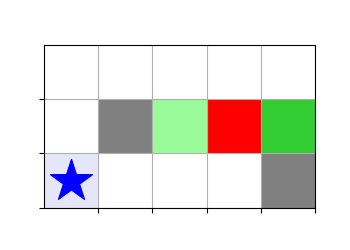

In [15]:
ENV = GridEnv(MDP)

# With minimal exploration
biased_q = QTable(ENV.mdp.all_states, ENV.mdp.all_actions)
biased_q[State(0, 0), Action.RIGHT] = 0.1
biased_q[State(1, 0), Action.RIGHT] = 0.1
biased_q[State(2, 0), Action.UP] = 0.1

minimal_exploration_policy, Q = monte_carlo(ENV, 100_000, eps_start=0.05, start_q=biased_q)
run_simulation(ENV.mdp, minimal_exploration_policy)

Episode 100000/100000.

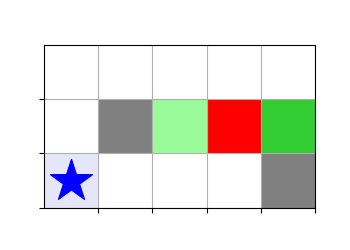

In [16]:
# With exploration
optimal_policy, Q = monte_carlo(ENV, 100_000, start_q=biased_q)
run_simulation(ENV.mdp, optimal_policy)

### Exploration vs. Exploitation Tradeoff

We can prove that MC converges to the optimal policy when these conditions are met:

- Every state-action pair is visited infinitely many times; and
- The policy converges to a policy that is greedy with respect to the action-value function Q.

These are called the GLIE (Greedy in the Limit with Infinite Exploration) conditions, and guarantee
that the agent continues exploring for all time steps, and gradually exploits more exploring less.

Let's probe the exploration knob directly. Our grid has _two_ terminal rewards — the nearby Target
`T` (+1.0) and the further-away Glory `G` (+10.0) — so we can see both whether a policy converges
_and_ which optimum it converged to. For each $\epsilon$ start we'll train MC, then roll the
resulting greedy policy over 200 evaluation episodes and tally which terminal they land on.


In [17]:
def evaluate_policy(env: GridEnv, policy: Policy, n_eval=200, max_t=20) -> float:
    """Rollout `n_eval` episodes under `policy` and return the average (undiscounted) return."""
    returns = []
    for _ in range(n_eval):
        ep = generate_episode(env, policy, max_t=max_t)
        returns.append(sum(r for _, _, r in ep))
    return float(np.mean(returns))


def terminal_breakdown(env: GridEnv, policy: Policy, n_eval=200, max_t=20) -> dict[str, int]:
    """Roll out `n_eval` episodes and tally which terminal (if any) they land on.

    The rewards are fixed (Target=+1.0, Glory=+10.0, Nuke=-10.0, else 0) and the episode
    breaks as soon as the environment reports `done`, so the *last* reward in each episode
    is the terminal reward — or ~0 if the episode was truncated by `max_t` without
    terminating.
    """
    counts = {"Glory": 0, "Target": 0, "truncated": 0}
    for _ in range(n_eval):
        ep = generate_episode(env, policy, max_t=max_t)
        last_reward = ep[-1][2] if ep else 0.0
        if abs(last_reward - 10.0) < 0.1:
            counts["Glory"] += 1
        elif abs(last_reward - 1.0) < 0.1:
            counts["Target"] += 1
        else:
            counts["truncated"] += 1
    return counts


# Sweep epsilon start and evaluate the resulting greedy policy.
print(f"{'eps_start':>10} | {'avg_return':>10} | {'Glory':>6} | {'Target':>6} | {'trunc':>6}")
print("-" * 55)
for eps_start in [0.0, 0.05, 0.3, 1.0]:
    policy, _ = monte_carlo(ENV, 20_000, eps_start=eps_start)
    avg = evaluate_policy(ENV, policy)
    br = terminal_breakdown(ENV, policy)
    print(
        f"\r{eps_start:>10.2f} | {avg:>10.3f} | "
        f"{br['Glory']:>6d} | {br['Target']:>6d} | {br['truncated']:>6d}"
    )

 eps_start | avg_return |  Glory | Target |  trunc
-------------------------------------------------------
      0.00 |      1.000 |      0 |    200 |      0
      0.05 |      1.000 |      0 |    200 |      0
      0.30 |     10.000 |    200 |      0 |      0
      1.00 |      0.000 |      0 |      0 |    200


Read across the rows and the sweet-spot story emerges cleanly:

- $\epsilon = 0$ and $\epsilon = 0.05$: MC converges, but to the _nearby_ Target (+1.0). With too
  little exploration the agent commits to the first terminal it stumbles into — a classic
  local-optimum trap.
- $\epsilon = 0.30$: enough exploration to discover the further-away Glory (+10.0), and the decay
  schedule then lets the agent _exploit_ that better policy. 200/200 evaluation episodes reach
  Glory.
- $\epsilon = 1.0$: pure random. The policy never stabilizes — every evaluation episode truncates
  without reaching a terminal.

This is exactly why the GLIE conditions matter: we need _enough_ exploration to see the full reward
landscape, but we also need to _gradually_ reduce it so the agent can commit to the good policy it
found.


## Temporal Difference Methods

Monte Carlo methods need to wait until the end of the episode to update our value estimates. Could
we find a way to integrate knowledge earlier than that? Temporal Difference (TD) methods come to the
rescue: they update the current value estimate based on the immediate reward and _another_ estimate.
Hence, the update rule looks something like this:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \{[R_t + \gamma V^{estimate}(S_{t+1})] - Q(S_t, A_t)\}
$$

$R_t + \gamma V^{estimate}(S_{t+1})$ is called the _TD target_. If our estimate was perfect, you can
notice it is effectively equivalent to $G_t$. Then, the _TD error_ $\delta^{TD}$ is:
$TD^{target} - Q(S_t, A_t)$. The equation above can be simplified as:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \delta^{TD}
$$

Choosing the estimate of the value function is what differentiates various TD algorithms.


### Q Learning

Q Learning is probably the most popular TD algorithm. In Q Learning, we choose the estimate of the
next value as: $\max Q(S_{t+1}, A_{t+1})$.


In [18]:
def q_learning(env: GridEnv, num_episodes, alpha=0.02, max_t=10):
    """Runs Q Learning."""
    Q = QTable(env.mdp.all_states, env.mdp.all_actions)
    epsilon = epsilon_gen(eps_decay=0.999999)
    # Run for the maximum number of episodes passed as input.
    for i_episode in range(1, num_episodes + 1):
        t = 0
        state = env.reset()
        while True:
            policy = epsilon_greedy_policy(Q, next(epsilon))
            action = policy(state)
            next_state, reward, done = env.step(action)
            cur_value = Q[state, action]
            next_action = Q.best_action(next_state)
            td_target = reward + env.mdp.gamma * Q[next_state, next_action]
            td_error = td_target - cur_value
            Q[state, action] = cur_value + alpha * td_error
            state = next_state
            t = t + 1
            if done or t >= max_t:
                break
        # Monitor and debugging messages.
        if i_episode % 1000 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
    policy = greedy_policy(Q)
    return policy, Q

Episode 100000/100000

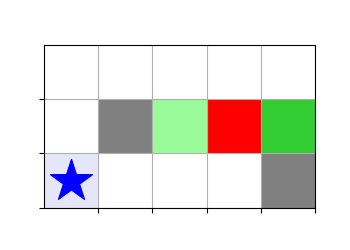

In [19]:
opt_policy, Q = q_learning(ENV, 100_000)
run_simulation(ENV.mdp, opt_policy)

In order to converge, Q Learning needs to explore enough and eventually make the learning rate small
enough, but not decrease it too quickly either... :)


### Off-Policy vs. On-Policy

Q Learning is an _off-policy_ algorithm: the policy function is learnt by estimating the value of
the next state using a separate policy (i.e., the greedy policy, maximizing the current Q value)
compared to the policy that is actually followed (i.e., $\epsilon$-greedy).

That is different from _on-policy_ learning, where we learn and refine the policy function using
actions taken via our current followed and learnt policy $\pi(a|s)$. See
[this post](https://stats.stackexchange.com/questions/184657/what-is-the-difference-between-off-policy-and-on-policy-learning)
for a more in-depth explanation.


### SARSA: An On-Policy TD Algorithm

[SARSA](https://en.wikipedia.org/wiki/State%E2%80%93action%E2%80%93reward%E2%80%93state%E2%80%93action)
is the classic on-policy counterpart to Q-Learning. The name comes directly from the five quantities
used in its update: $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$.

The only difference from Q-Learning is in the TD target: instead of the $\max$ over the next
state-action values (i.e., the greedy policy's estimate), SARSA uses the Q value of the action
_actually selected_ by the behavior policy for the next step:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma\, Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]
$$

That small change has a meaningful consequence: SARSA learns the value of the $\epsilon$-greedy
policy it is _actually following_, exploratory mistakes included. As a result, SARSA tends to learn
safer policies in environments where exploration is risky — the textbook example is cliff-walking,
where SARSA prefers a longer route away from the edge while Q-Learning happily hugs the cliff
because it evaluates the greedy policy it would follow _if_ exploration stopped.


In [20]:
def sarsa(env: GridEnv, num_episodes, alpha=0.02, max_t=10):
    """Runs SARSA (on-policy TD)."""
    Q = QTable(env.mdp.all_states, env.mdp.all_actions)
    epsilon = epsilon_gen(eps_decay=0.999999)
    for i_episode in range(1, num_episodes + 1):
        t = 0
        state = env.reset()
        # SARSA needs the next action *before* doing the TD update, so we pick the first action up
        # front and then advance state and action together with the environment.
        policy = epsilon_greedy_policy(Q, next(epsilon))
        action = policy(state)
        while True:
            next_state, reward, done = env.step(action)
            # The next action is chosen by the *same* behavior policy we're following -- this is
            # what makes SARSA on-policy. We refresh epsilon so each step sees the decayed value.
            policy = epsilon_greedy_policy(Q, next(epsilon))
            next_action = policy(next_state)
            cur_value = Q[state, action]
            # Key difference vs. Q-Learning: target uses Q(next_state, next_action), NOT max Q.
            td_target = reward + env.mdp.gamma * Q[next_state, next_action]
            td_error = td_target - cur_value
            Q[state, action] = cur_value + alpha * td_error
            # Advance state and action in lockstep.
            state, action = next_state, next_action
            t = t + 1
            if done or t >= max_t:
                break
        if i_episode % 1000 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
    policy = greedy_policy(Q)
    return policy, Q

Episode 100000/100000

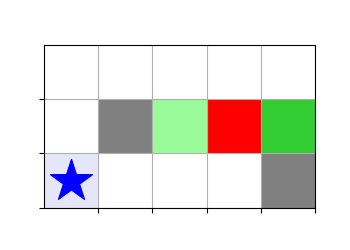

In [21]:
sarsa_policy, Q = sarsa(ENV, 100_000)
run_simulation(ENV.mdp, sarsa_policy)

**Bonus — Expected SARSA.** A common middle-ground variant replaces the single sample
$Q(S_{t+1}, A_{t+1})$ in the TD target with its _expectation_ under the behavior policy:
$\sum_a \pi(a\,|\,S_{t+1})\, Q(S_{t+1}, a)$. This reduces the variance of the update without
changing its bias, and for a small amount of extra compute per step is usually strictly better than
vanilla SARSA.


## Comparing MC, Q-Learning, and SARSA

With three algorithms on the same environment, we can finally compare them head-to-head. We train
each one for the same number of episodes and evaluate the final greedy policy by rolling it out on
`ENV`.


In [22]:
init_random()

NUM_EPISODES = 30_000
results = []
for name, fn in [
    ("Monte Carlo", lambda: monte_carlo(ENV, NUM_EPISODES, start_q=biased_q)),
    ("Q-Learning", lambda: q_learning(ENV, NUM_EPISODES)),
    ("SARSA", lambda: sarsa(ENV, NUM_EPISODES)),
]:
    policy, _ = fn()
    results.append((name, evaluate_policy(ENV, policy), terminal_breakdown(ENV, policy)))

print()
print(f"{'Algorithm':<15} | {'Avg. Return':>12} | {'Glory':>6} | {'Target':>6} | {'trunc':>6}")
print("-" * 60)
for name, ret, br in results:
    print(
        f"{name:<15} | {ret:>12.3f} | "
        f"{br['Glory']:>6d} | {br['Target']:>6d} | {br['truncated']:>6d}"
    )

Episode 30000/30000.
Algorithm       |  Avg. Return |  Glory | Target |  trunc
------------------------------------------------------------
Monte Carlo     |        1.000 |      0 |    200 |      0
Q-Learning      |       10.000 |    200 |      0 |      0
SARSA           |        1.000 |      0 |    200 |      0


The grid has _two_ terminal rewards: the nearby Target `T` (+1.0) and the further-away Glory `G`
(+10.0). Reaching `G` requires skirting the Nuke `N` (-10.0), so $\epsilon$-greedy exploration along
that path occasionally blows up. Each algorithm handles that risk differently:

- **Q-Learning** finds `G`. Its TD target uses $\max_a Q(S_{t+1}, a)$ — it evaluates the _greedy_
  policy it will eventually follow, which won't slip into `N`. From Q-Learning's perspective, the
  `G` path is worth ~10 and the `T` path is worth ~1, so it commits to `G`.
- **SARSA** settles for `T`. Its TD target uses $Q(S_{t+1}, A_{t+1})$ where $A_{t+1}$ is the action
  _actually_ taken by the current $\epsilon$-greedy behavior, which sometimes slips into `N`. SARSA
  learns the value of the policy it's really following, nukes included, so the `G` path looks risky
  and `T` becomes the better bet.
- **Monte Carlo** also ends up at `T`, but for a different reason: we seeded it with `biased_q`
  pointing toward `T`, and 30k episodes weren't enough exploration to overcome that prior.

This is the classic _cliff-walking_ contrast from Sutton & Barto playing out on our tiny grid.

**What would make SARSA find Glory too?** The risk-aversion is driven by how much $\epsilon$ SARSA
still sees during training. With the default `eps_decay=0.999999`, after 30k episodes $\epsilon$ has
only decayed from `1.0` to ~`0.74` — the behavior policy is still highly exploratory at the _end_,
so SARSA keeps attributing Nuke penalties to the Glory path. Try re-running SARSA with a faster
decay (e.g. `eps_decay=0.99999`, one fewer 9): once $\epsilon$ actually falls toward `eps_min`, the
exploration-induced risk disappears and SARSA should start matching Q-Learning.


## Bridging MC and TD: n-step and $\lambda$-returns

Monte Carlo and TD(0) sit at opposite ends of a spectrum: MC uses the _entire_ trajectory to form
its target; TD(0) uses just the next reward plus a bootstrap. Nothing forces us to pick an extreme —
we can use the next $n$ rewards and then bootstrap, producing the **n-step return**:

$$
G_t^{(n)} = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{n-1} R_{t+n} + \gamma^n\, Q(S_{t+n}, A_{t+n})
$$

TD(0) is the $n{=}1$ case; MC is $n{=}\infty$. Intermediate values of $n$ trade bias (shorter $n$,
more bootstrapping error) against variance (longer $n$, more stochasticity in the return).

A more elegant generalization is the **$\lambda$-return**, which averages all n-step returns with
exponentially decaying weights $\lambda^{n-1}$, controlled by a single parameter
$\lambda \in [0, 1]$. You will see this idea again later in the course:
_[Generalized Advantage Estimation (GAE)](https://arxiv.org/abs/1506.02438)_, used in PPO and other
policy-gradient methods, is essentially a $\lambda$-return applied to advantages rather than Q
values. For a deeper treatment of n-step methods and TD($\lambda$), Chapters 7 and 12 of
[Sutton and Barto](http://incompleteideas.net/book/RLbook2020.pdf) are the canonical reference.


## Tabular Methods Limitations

Cannot scale to large state / action spaces. Discretization is one approach, but there are better
ones :)
